# Exploring metric scores on trans proteomic pipeline workflows 

In [8]:
import pandas as pd
import sys
import os
import itertools
import matplotlib.pyplot as plt
import json

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../src')))

from wfqc.metrics import *
from wfqc.network import create_citation_network


In [3]:
graph = create_citation_network(inpath='../out_202407041439')

Loading saved data.


In [4]:
tpp_tools = pd.read_csv('../TPP.csv')
tpp_tools = tpp_tools.dropna(subset=["id"])

In [5]:
tpp_tools['id'] = tpp_tools['id'].astype(int)
tpp_tools['id'] = tpp_tools['id'].astype(str)
tpp_tools['name'] = tpp_tools['name'].astype(str)

In [162]:
list(tpp_tools.columns.values)

['name', 'position', 'id', 'comment']

There are 6 different positions, only one tool can be used in each position at a time, and there is a varying amount of choices per position. The method below creates all the permutations of possible tool combinations based on a list of position. 

In [6]:
def tool_permutations(tools_by_positions):
    position_values = list(tools_by_positions.values())
    all_combinations = list(itertools.product(*position_values))
    return all_combinations

def tuple_workflow_from_list(list_workflow):
    tuple_workflow = []
    number_tools = len(list_workflow)
    for i in range(number_tools):
        for j in range(i, number_tools):
            tuple_workflow.append( ( list_workflow[i], list_workflow[j] ) )
    return tuple_workflow


In [ ]:
tools_by_positions = {}
for i in range(1, 7):
    tools_by_positions[i] = tpp_tools[tpp_tools['position'] == i]['id'].tolist()

In [184]:
all_combinations = tool_permutations(tools_by_positions)

In [185]:
print(len(all_combinations))

486


In [187]:
# Define them as sets of tuples, edges, instead
tuple_workflows = [tuple_workflow_from_list(workflow) for workflow in all_combinations]

In [188]:
# calculate metric scores for each 
metric_scores = [complete_tree(graph, workflow) for workflow in tuple_workflows]

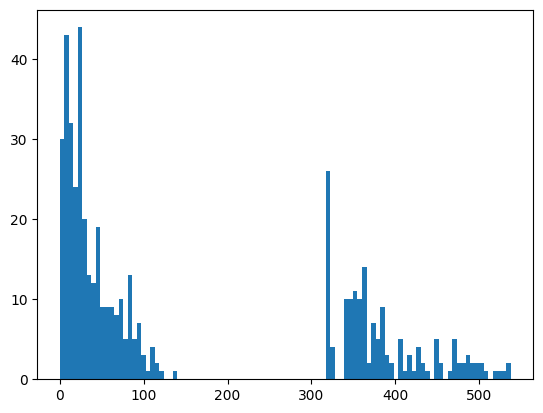

In [189]:
plt.hist(metric_scores, bins=100)
plt.show()

Position 3 choice of tool splits the dataset (PeptideProphet, PTMprophet and iProphet) so lets look at them each separately 

In [ ]:
pos_three_candidates = ['PeptideProphet', 'PTMprophet', 'iProphet']
candidate_scores = []
candidate_tuples = []
for candidate in pos_three_candidates:
    non_candidates = [c for c in pos_three_candidates if c != candidate]
    tpp_tool_dropped_candidate = tpp_tools[tpp_tools['name']!= non_candidates[0]]
    tpp_tool_dropped_candidate = tpp_tool_dropped_candidate[tpp_tool_dropped_candidate['name']!= non_candidates[1]]
    tools_by_positions = {}
    
    for i in range(1, 7):
        tools_by_positions[i] = tpp_tool_dropped_candidate[tpp_tool_dropped_candidate['position'] == i]['id'].tolist()

    all_combinations = tool_permutations(tools_by_positions)
    tuple_workflows = [tuple_workflow_from_list(workflow) for workflow in all_combinations]
    metric_scores = [complete_tree(graph, workflow) for workflow in tuple_workflows]

    candidate_tuples.append(tuple_workflows)
    candidate_scores.append(metric_scores)

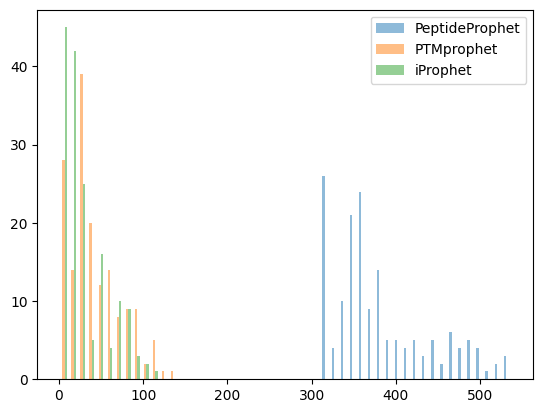

In [211]:

plt.hist(candidate_scores, bins=50, alpha=0.5, label=pos_three_candidates)
plt.legend()
plt.show()


In [11]:
with open('../out_202407041439/edgestopic_0121.json', "r") as f: # as generated by create_citation_network
    citation_data_file = json.load(f)

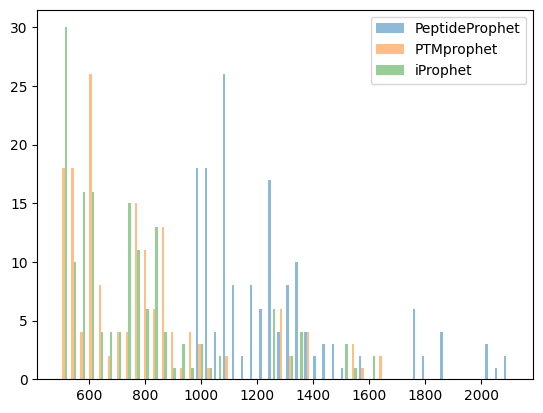

In [27]:
# difference if using median 
pos_three_candidates = ['PeptideProphet', 'PTMprophet', 'iProphet']
candidate_scores = []
candidate_tuples = []

for candidate in pos_three_candidates:
    non_candidates = [c for c in pos_three_candidates if c != candidate]
    tpp_tool_dropped_candidate = tpp_tools[tpp_tools['name']!= non_candidates[0]]
    tpp_tool_dropped_candidate = tpp_tool_dropped_candidate[tpp_tool_dropped_candidate['name']!= non_candidates[1]]
    tools_by_positions = {}
    
    for i in range(1, 7):
        tools_by_positions[i] = tpp_tool_dropped_candidate[tpp_tool_dropped_candidate['position'] == i]['id'].tolist()

    all_combinations = tool_permutations(tools_by_positions)
    tuple_workflows = [tuple_workflow_from_list(workflow) for workflow in all_combinations]
    metric_scores = [citations( workflow, citation_data_file) for workflow in tuple_workflows]

    candidate_tuples.append(tuple_workflows)
    candidate_scores.append(metric_scores)

plt.hist(candidate_scores, bins=50, alpha=0.5, label=pos_three_candidates)
plt.legend()
plt.show()
